In [10]:
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import norm, laplace, t, gennorm, probplot
from scipy.special import gamma

import matplotlib.pyplot as plt

# Narrow Peak w/ Fat Tails

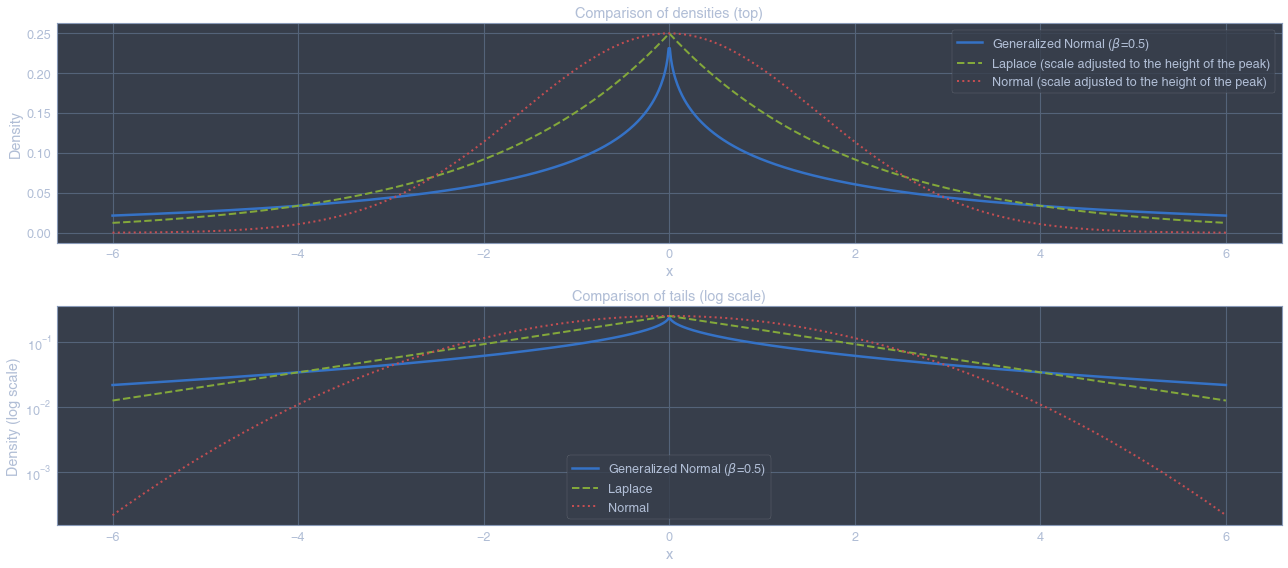

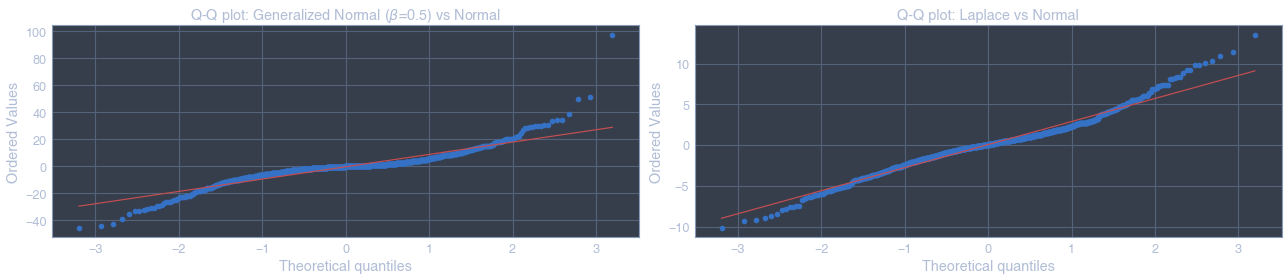

In [20]:
beta = 0.5  # < 1 — острый пик + тяжёлые хвосты
scale = 1.0

x = np.linspace(-6, 6, 1000)

# 1. Обобщённое нормальное (Generalized Normal) с β=0.5
# В scipy это gennorm(beta, loc, scale)
dist_gennorm = gennorm(beta, loc=0, scale=scale)
pdf_gennorm = dist_gennorm.pdf(x)

# 2. Лаплас (для сравнения) — подбираем масштаб, чтобы пик был такой же высоты
# Пик Лапласа = 1/(2b) где b — масштаб. Хотим, чтобы высота пика совпала с gennorm
peak_height_gennorm = dist_gennorm.pdf(0)
scale_laplace = 1 / (2 * peak_height_gennorm)
dist_laplace = laplace(loc=0, scale=scale_laplace)
pdf_laplace = dist_laplace.pdf(x)

# 3. Нормальное распределение (для контраста) — подбираем масштаб под ту же высоту пика
sigma_norm = 1 / (peak_height_gennorm * np.sqrt(2 * np.pi))
dist_norm = norm(loc=0, scale=sigma_norm)
pdf_norm = dist_norm.pdf(x)


fig, axs = plt.subplots(2, 1, figsize=(18, 8))

# График плотности
axs[0].plot(x, pdf_gennorm, label=f'Generalized Normal ($β$={beta})', lw=2.5)
axs[0].plot(x, pdf_laplace, label=f'Laplace (scale adjusted to the height of the peak)', lw=2, linestyle='--')
axs[0].plot(x, pdf_norm, label=f'Normal (scale adjusted to the height of the peak)', lw=2, linestyle=':')
axs[0].set_title('Comparison of densities (top)')
axs[0].set_xlabel('x')
axs[0].set_ylabel('Density')
axs[0].legend()

# График хвостов (логарифмическая шкала)
axs[1].semilogy(x, pdf_gennorm, label=f'Generalized Normal ($β$={beta})', lw=2.5)
axs[1].semilogy(x, pdf_laplace, label='Laplace', lw=2, linestyle='--')
axs[1].semilogy(x, pdf_norm, label='Normal', lw=2, linestyle=':')
axs[1].set_title('Comparison of tails (log scale)')
axs[1].set_xlabel('x')
axs[1].set_ylabel('Density (log scale)')
axs[1].legend()

plt.tight_layout()


np.random.seed(42)
n_samples = 1000
samples_gennorm = dist_gennorm.rvs(size=n_samples)
samples_laplace = dist_laplace.rvs(size=n_samples)

fig, axs = plt.subplots(1, 2, figsize=(18, 4))

probplot(samples_gennorm, dist='norm', plot=axs[0])
axs[0].set_title(f'Q-Q plot: Generalized Normal ($β$={beta}) vs Normal')

probplot(samples_laplace, dist='norm', plot=axs[1])
axs[1].set_title('Q-Q plot: Laplace vs Normal')

plt.tight_layout()


In [21]:
print(f'kurtosis of Generalized Normal (β={beta}): {stats.kurtosis(samples_gennorm, fisher=True):.2f}')
print(f'kurtosis of Laplace: {stats.kurtosis(samples_laplace, fisher=True):.2f}')
print(f'kurtosis of Normal: {stats.kurtosis(np.random.normal(0, 1, n_samples), fisher=True):.2f}')

kurtosis of Generalized Normal (β=0.5): 13.17
kurtosis of Laplace: 2.00
kurtosis of Normal: 0.15


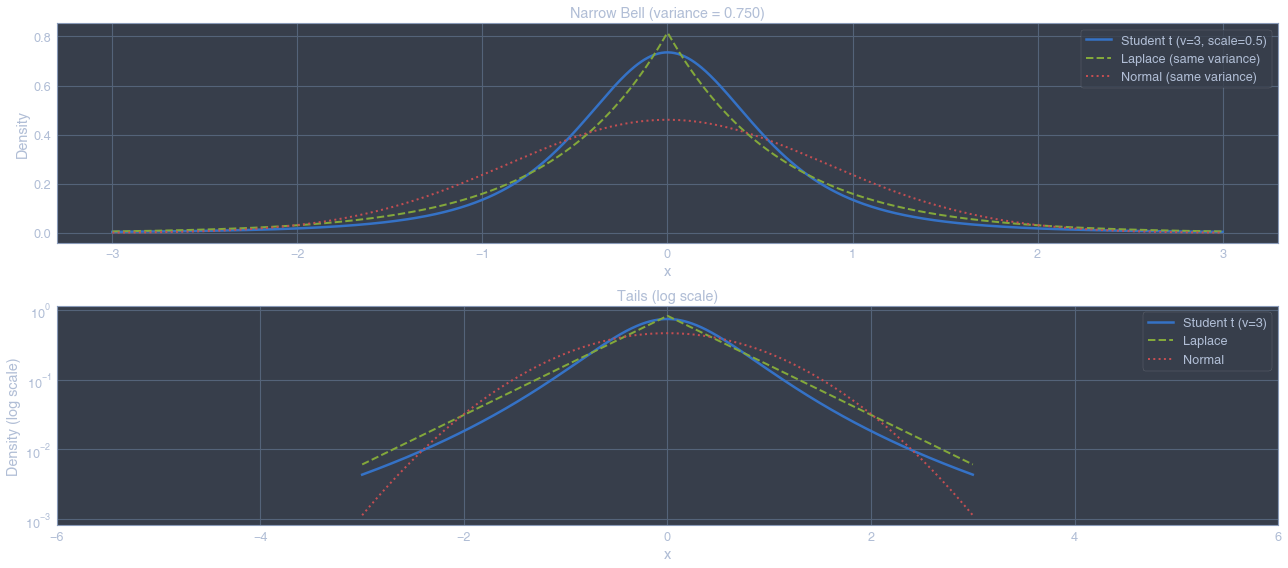

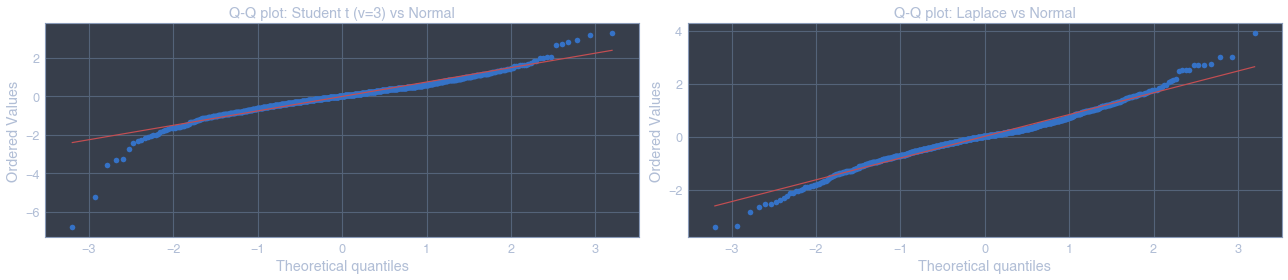

In [31]:
# Параметры
df = 3  # степени свободы: чем меньше, тем тяжелее хвосты
scale_t = 0.5  # маленький масштаб = узкий колокол
loc = 0

# Генерируем распределения
dist_t = t(df=df, loc=loc, scale=scale_t)

# Для сравнения: Лаплас с такой же дисперсией
# Дисперсия t-распределения: df/(df-2) * scale^2
variance_t = (df/(df-2)) * (scale_t**2) if df > 2 else np.inf
if df > 2:
    # Приводим Лаплас к той же дисперсии
    # Дисперсия Лапласа: 2 * scale_laplace^2
    scale_laplace = np.sqrt(variance_t / 2)
    dist_laplace = laplace(loc=loc, scale=scale_laplace)
else:
    # Для df=3 (существует) -> нормально
    scale_laplace = np.sqrt(variance_t / 2)
    dist_laplace = laplace(loc=loc, scale=scale_laplace)

# Нормальное распределение с той же дисперсией
dist_norm = norm(loc=loc, scale=np.sqrt(variance_t))

# Визуализация
x = np.linspace(-3, 3, 1000)
pdf_t = dist_t.pdf(x)
pdf_laplace = dist_laplace.pdf(x)
pdf_norm = dist_norm.pdf(x)

fig, axs = plt.subplots(2, 1, figsize=(18, 8))

axs[0].plot(x, pdf_t, label=f'Student t (v={df}, scale={scale_t})', lw=2.5)
axs[0].plot(x, pdf_laplace, label='Laplace (same variance)', lw=2, linestyle='--')
axs[0].plot(x, pdf_norm, label='Normal (same variance)', lw=2, linestyle=':')
axs[0].set_title(f'Narrow Bell (variance = {variance_t:.3f})')
axs[0].set_xlabel('x')
axs[0].set_ylabel('Density')
axs[0].legend()

axs[1].semilogy(x, pdf_t, label=f'Student t (v={df})', lw=2.5)
axs[1].semilogy(x, pdf_laplace, label='Laplace', lw=2, linestyle='--')
axs[1].semilogy(x, pdf_norm, label='Normal', lw=2, linestyle=':')
axs[1].set_title('Tails (log scale)')
axs[1].set_xlabel('x')
axs[1].set_ylabel('Density (log scale)')
axs[1].set_xlim(-6, 6)
axs[1].legend()

plt.tight_layout()

samples_t = dist_t.rvs(size=1000)
samples_laplace = dist_laplace.rvs(size=1000)

fig, axs = plt.subplots(1, 2, figsize=(18, 4))

probplot(samples_t, dist='norm', plot=axs[0])
axs[0].set_title(f'Q-Q plot: Student t (v={df}) vs Normal')

probplot(samples_laplace, dist='norm', plot=axs[1])
axs[1].set_title('Q-Q plot: Laplace vs Normal')

plt.tight_layout()


In [32]:
print(f'variance t-distribution: {variance_t:.4f}')
print(f'kurtosis Student t (ν={df}): {stats.kurtosis(samples_t, fisher=True):.2f}')
print(f'kurtosis Laplace: {stats.kurtosis(samples_laplace, fisher=True):.2f}')
print(f'kurtosis Normal: {stats.kurtosis(dist_norm.rvs(size=1000), fisher=True):.2f}')

variance t-distribution: 0.7500
kurtosis Student t (ν=3): 9.34
kurtosis Laplace: 1.87
kurtosis Normal: -0.23
